In [6]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
%matplotlib inline


When we look at any image, most of the time we identify a person using a face. An image might contain multiple faces, also the face can be obstructed and not clear. The first step in our pre-processing pipeline is to detect faces from an image. Once face is detected, we will detect eyes, if two eyes are detected then only we keep that image otherwise discard it.
Now how do you detect face and eyes?

We will use haar cascade from opencv for this. Here is an article on this: https://opencv-python-tutroals.readthedocs.io/en/latest/py_tutorials/py_objdetect/py_face_detection/py_face_detection.html?highlight=haar


In [9]:
import os
os.getcwd()


'd:\\PROJECTS\\Celebrity Classn'

In [21]:
img = cv2.imread("tesimage/sharapova1.jpg")
img.shape

(555, 700, 3)

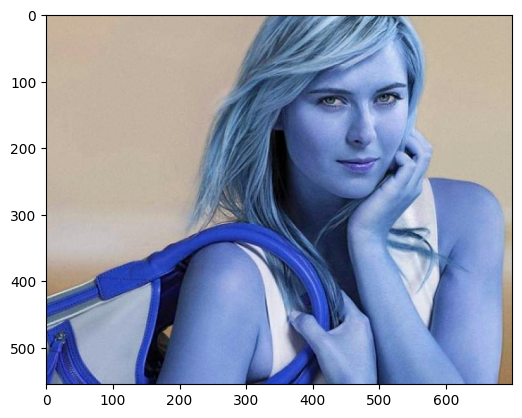

In [22]:
plt.imshow(img)

In [23]:
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray.shape

(555, 700)

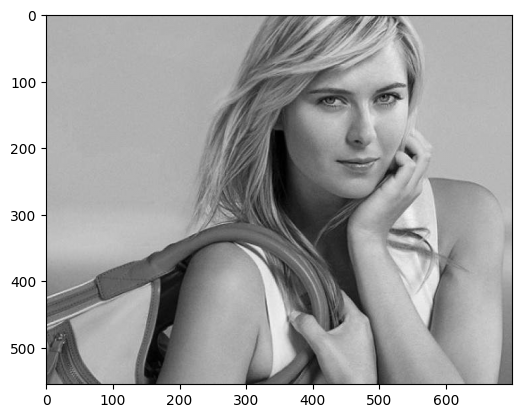

In [24]:
plt.imshow(gray,cmap='gray')

In [25]:
face_cascade = cv2.CascadeClassifier('haarcasacdes/haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('haarcasacdes/haarcascade_eye.xml')

faces = face_cascade.detectMultiScale(gray, 1.3, 5)
faces

array([[352,  38, 233, 233]], dtype=int32)

In [26]:
(x,y,w,h) = faces[0]
x,y,w,h

(np.int32(352), np.int32(38), np.int32(233), np.int32(233))

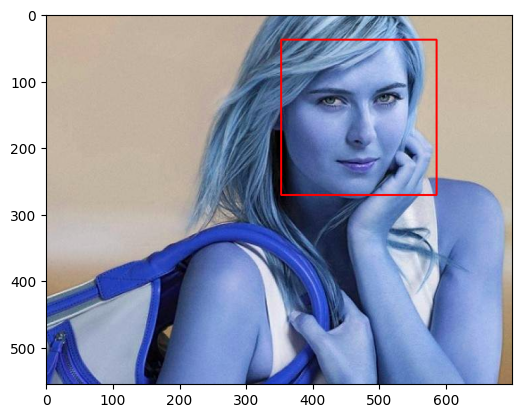

In [27]:
face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
plt.imshow(face_img)



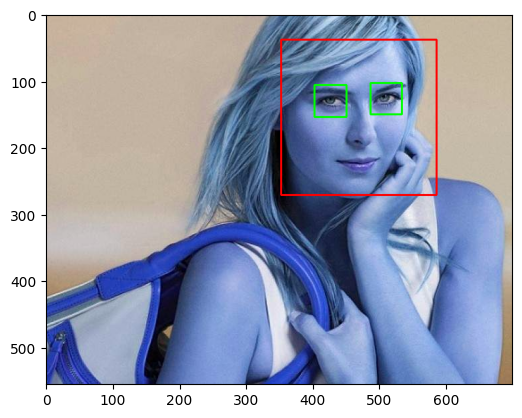

In [28]:
for (x,y,w,h) in faces:
    face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = face_img[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)


plt.figure()
plt.imshow(face_img, cmap='gray')
plt.show()

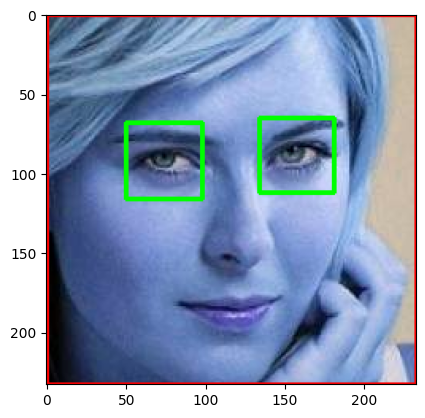

In [29]:
%matplotlib inline
plt.imshow(roi_color, cmap='gray')

Function to get image path -> convert to gray -> detect face (red) -> detect eye (blue) -> return

In [45]:
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    print(image_path, "Faces:", len(faces))

    for (x,y,w,h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)

        print("  Eyes detected:", len(eyes))

        if len(eyes) >= 2:
            return img[y:y+h, x:x+w]

    return None


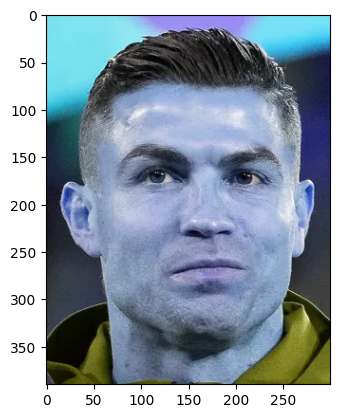

In [31]:
img2 = cv2.imread("tesimage/8198-1748102259.webp")
plt.imshow(img2)

tesimage/8198-1748102259.webp Faces: 1
  Eyes detected: 2


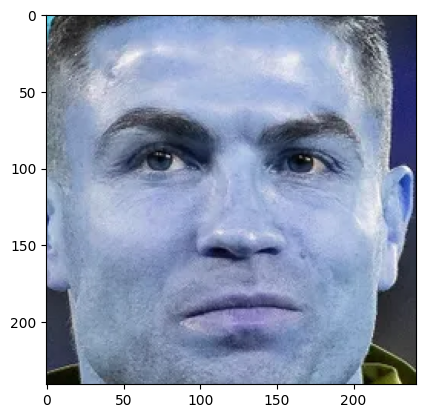

In [46]:
cropped_img = get_cropped_image_if_2_eyes("tesimage/8198-1748102259.webp")
if cropped_img is not None:
    plt.imshow(cropped_img)
else:
    print("No face with two eyes detected or cropped image not found.")

In [33]:
path_to_data = "Dataset/"
path_to_cr_data = "Dataset/cropped/"



In [83]:
import os
img_dirs = []
for entry in os.scandir(path_to_data):
    if entry.is_dir():
        img_dirs.append(entry.path)

In [84]:
img_dirs

['Dataset/cristiano ronaldo',
 'Dataset/cropped',
 'Dataset/dwayne jhonson',
 'Dataset/novak djokovic',
 'Dataset/serena williams',
 'Dataset/Virat Kohli']

In [85]:
import shutil
if os.path.exists(path_to_cr_data):
     shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

In [86]:
cropped_image_dirs = []
celebrity_file_names_dict = {}

for img_dir in img_dirs:
    count = 1
    celebrity_name = img_dir.split('/')[-1]
    print(celebrity_name)
    
    celebrity_file_names_dict[celebrity_name] = []
    
    for entry in os.scandir(img_dir):
        if not entry.is_file():
            continue
    
        if not entry.name.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue
        roi_color = get_cropped_image_if_2_eyes(entry.path)
        if roi_color is not None:
            cropped_folder = path_to_cr_data + celebrity_name
            if not os.path.exists(cropped_folder):
                os.makedirs(cropped_folder)
                cropped_image_dirs.append(cropped_folder)
                print("Generating cropped images in folder: ",cropped_folder)
                
            cropped_file_name = celebrity_name + str(count) + ".png"
            cropped_file_path = cropped_folder + "/" + cropped_file_name 
            
            cv2.imwrite(cropped_file_path, roi_color)
            celebrity_file_names_dict[celebrity_name].append(cropped_file_path)
            count += 1    

cristiano ronaldo
Dataset/cristiano ronaldo\000_32kv2m6.JPEG Faces: 1
  Eyes detected: 2
Generating cropped images in folder:  Dataset/cropped/cristiano ronaldo
Dataset/cristiano ronaldo\0154c130-e3a7-11ef-8450-ff58a15d40df.JPEG Faces: 1
  Eyes detected: 4
Dataset/cristiano ronaldo\0x0.JPEG Faces: 0
Dataset/cristiano ronaldo\1579_cristiano_ronaldo_20251228003106.PNG Faces: 1
  Eyes detected: 6
Dataset/cristiano ronaldo\17546972457383.JPEG Faces: 1
  Eyes detected: 0
Dataset/cristiano ronaldo\186067c3c81040a68a049b9344b9f995.JPEG Faces: 0
Dataset/cristiano ronaldo\1oup8rgk.JPEG Faces: 1
  Eyes detected: 3
Dataset/cristiano ronaldo\2026-01-12t181948z_1201909185_up1em1c1ewzpk_rtrmadp_3_soccer-saudi-hil-nsr.JPEG Faces: 2
  Eyes detected: 0
  Eyes detected: 1
Dataset/cristiano ronaldo\2241509215_large_cropped.JPEG Faces: 1
  Eyes detected: 2
Dataset/cristiano ronaldo\2241646348_large_cropped.JPEG Faces: 1
  Eyes detected: 4
Dataset/cristiano ronaldo\250px-c.JPEG Faces: 0
Dataset/cristiano r

(3) Preprocessing: Use wavelet transform as a feature for traning our model
Wavelet transform

In wavelet transformed image, you can see edges clearly and that can give us clues on various facial features such as eyes, nose, lips etc

In [88]:
import numpy as np
import pywt
import cv2    

def w2d(img, mode='haar', level=1):
    imArray = img
    #Datatype conversions
    #convert to grayscale
    imArray = cv2.cvtColor( imArray,cv2.COLOR_RGB2GRAY )
    #convert to float
    imArray =  np.float32(imArray)   
    imArray /= 255;
    # compute coefficients 
    coeffs=pywt.wavedec2(imArray, mode, level=level)

    #Process Coefficients
    coeffs_H=list(coeffs)  
    coeffs_H[0] *= 0;  

    # reconstruction
    imArray_H=pywt.waverec2(coeffs_H, mode);
    imArray_H *= 255;
    imArray_H =  np.uint8(imArray_H)

    return imArray_H

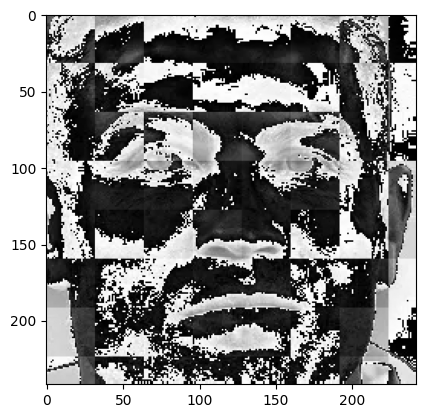

In [89]:


im_har = w2d(cropped_img,'db1',5)
plt.imshow(im_har, cmap='gray')



Assign values to Celebrities

In [92]:
class_dict = {}
count = 1
for celebrity_name in celebrity_file_names_dict.keys():
    if celebrity_name=="cropped":
        continue
    class_dict[celebrity_name] = count
    count = count + 1
class_dict

{'cristiano ronaldo': 1,
 'dwayne jhonson': 2,
 'novak djokovic': 3,
 'serena williams': 4,
 'Virat Kohli': 5}

Images in cropped folder can be used for model training. We will use these raw images along with wavelet transformed images to train our classifier. Let's prepare X and y now

In [93]:
im_har.shape

(242, 242)

In [94]:
x, y = [], []
for celebrity_name, training_files in celebrity_file_names_dict.items():
    for training_image in training_files:
        img = cv2.imread(training_image)
        if img is None:
            continue
        scalled_raw_img = cv2.resize(img, (32, 32))
        img_har = w2d(img,'db1',5)
        scalled_img_har = cv2.resize(img_har, (32, 32))
        combined_img = np.vstack((scalled_raw_img.reshape(32*32*3,1),scalled_img_har.reshape(32*32,1)))
        x.append(combined_img)
        y.append(class_dict[celebrity_name])

In [95]:
len(x[0])

4096

In [96]:
32*32*3 + 32*32

4096

In [97]:
x = np.array(x).reshape(len(x),4096).astype(float)
x.shape

(326, 4096)

In [145]:
y[0]

1

In [146]:
class_dict

{'cristiano ronaldo': 1,
 'dwayne jhonson': 2,
 'novak djokovic': 3,
 'serena williams': 4,
 'Virat Kohli': 5}

Data Cleaning done .Now ready to train model

In [70]:
!pip install scikit-Learn
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.0-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.0-cp311-cp311-win_amd64.whl (36.4 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------------------------------------- 0/4 [threadpoolctl]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------

In [99]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)

pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel = 'rbf', C = 10))])
pipe.fit(x_train, y_train)
pipe.score(x_test, y_test)

0.8170731707317073

In [100]:
print(classification_report(y_test, pipe.predict(x_test)))

              precision    recall  f1-score   support

           1       1.00      0.77      0.87        22
           2       0.74      0.86      0.79        29
           3       0.93      0.81      0.87        16
           4       0.62      0.73      0.67        11
           5       1.00      1.00      1.00         4

    accuracy                           0.82        82
   macro avg       0.86      0.83      0.84        82
weighted avg       0.84      0.82      0.82        82




Let's use GridSearch to try out different models with different paramets. Goal is to come up with best modle with best fine tuned parameters

In [101]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

In [127]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

log_model = OneVsRestClassifier(LogisticRegression(solver='liblinear', max_iter=1000))


In [128]:
model_params = {
    'svm': {
    'model': svm.SVC(probability=True),
    'params': {
        'model__C': [1, 10, 100, 1000],
        'model__kernel': ['rbf', 'linear']
    }
},
'random_forest': {
    'model': RandomForestClassifier(),
    'params': {
        'model__n_estimators': [5, 10, 20]
    }
}
,
    'logistic_regression': {
    'model': OneVsRestClassifier(LogisticRegression(solver='liblinear', max_iter=1000)),
    'params': {
        'model__estimator__C': [1, 5, 10],  # double underscore: step__wrapped__parameter
        'model__estimator__solver': ['liblinear']
    }
}

}

Scores for different models

In [109]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [129]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y_encoded, test_size=0.2, random_state=42
)


In [112]:
import collections
print(collections.Counter(y_train))


Counter({np.int64(1): 91, np.int64(0): 53, np.int64(2): 52, np.int64(3): 42, np.int64(4): 22})


In [120]:
import numpy as np

print("X shape:", x.shape)
print("NaNs:", np.isnan(x).any())
print("Infs:", np.isinf(x).any())
print(x.dtype)
x = np.array(x, dtype=np.float64)


X shape: (326, 4096)
NaNs: False
Infs: False
float64


In [132]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm

scores = []
best_estimators = {}

for algo, mp in model_params.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', mp['model'])
    ])

    clf = GridSearchCV(pipe, mp['params'], cv=3, return_train_score=False)
    clf.fit(x_train, y_train)

    scores.append({
        'model': algo,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })

    best_estimators[algo] = clf.best_estimator_
df = pd.DataFrame(scores,columns=['model','best_score','best_params'])
df

,model,best_score,best_params
0,svm,0.834714,"{'model__C': 1, 'model__kernel': 'linear'}"
1,random_forest,0.642342,{'model__n_estimators': 10}
2,logistic_regression,0.811414,"{'model__estimator__C': 1, 'model__estimator__..."


In [133]:
best_estimators

{'svm': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model', SVC(C=1, kernel='linear', probability=True))]),
 'random_forest': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model', RandomForestClassifier(n_estimators=10))]),
 'logistic_regression': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model',
                  OneVsRestClassifier(estimator=LogisticRegression(C=1,
                                                                   max_iter=1000,
                                                                   solver='liblinear')))])}

In [134]:
best_estimators['svm'].score(x_test,y_test)

0.8333333333333334

In [135]:
best_estimators['random_forest'].score(x_test,y_test)

0.6363636363636364

In [136]:
best_estimators['logistic_regression'].score(x_test,y_test)

0.8333333333333334

In [137]:
best_clf = best_estimators['svm']

In [139]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, best_clf.predict(x_test))
cm

array([[14,  0,  0,  0,  0],
       [ 2, 24,  0,  2,  0],
       [ 0,  2,  5,  1,  0],
       [ 1,  1,  0,  8,  0],
       [ 0,  0,  1,  1,  4]])

Text(95.72222222222221, 0.5, 'Truth')

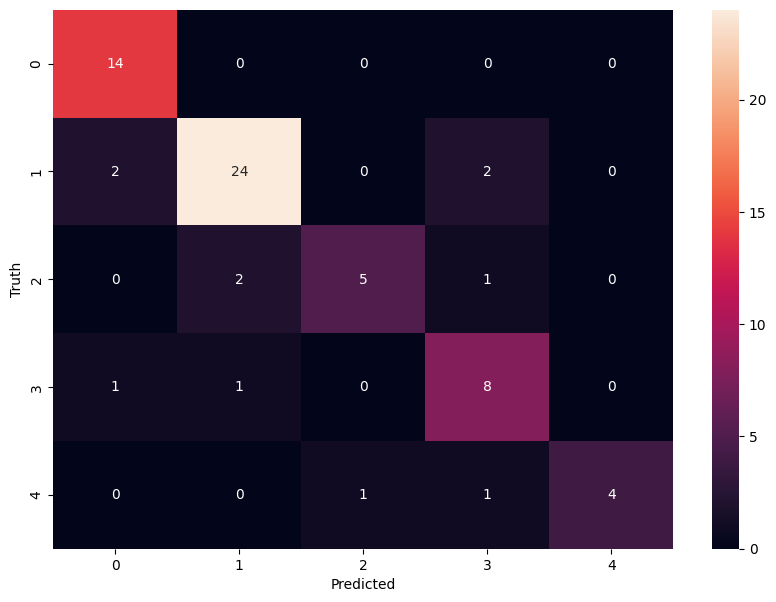

In [147]:
!pip install seaborn
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [149]:
!pip install joblib
import joblib
joblib.dump(best_clf,'best_clf_model.pkl')

['best_clf_model.pkl']

In [142]:
class_dict

{'cristiano ronaldo': 1,
 'dwayne jhonson': 2,
 'novak djokovic': 3,
 'serena williams': 4,
 'Virat Kohli': 5}

In [148]:
import json
with open("class_dictionary.json","w") as f:
    f.write(json.dumps(class_dict))